# EDA — GRUPO DE CONTROLE

Dataset: `ilkeryildiz/example-dataset-for-ab-test` · campanha `Control Campaign`.

Este notebook roda a partir da raiz do projeto. O CSV é separado por `;` e a
coluna de data vem em `dd.mm.aaaa`.

In [1]:
import pandas as pd

pd.set_option("display.width", 200)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette('husl')

In [3]:
# O CSV usa ';' como separador. O caminho e relativo a raiz do repo, entao
# o notebook roda em qualquer maquina depois de abrir a pasta do projeto.
df = pd.read_csv("../data/control_group.csv", sep=";")
df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y", dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)
print("GRUPO DE CONTROLE - {} dias".format(len(df)))

GRUPO DE CONTROLE - 30 dias


In [4]:
df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Campaign Name        30 non-null     str           
 1   Date                 30 non-null     datetime64[us]
 2   Spend [USD]          30 non-null     int64         
 3   # of Impressions     29 non-null     float64       
 4   Reach                29 non-null     float64       
 5   # of Website Clicks  29 non-null     float64       
 6   # of Searches        29 non-null     float64       
 7   # of View Content    29 non-null     float64       
 8   # of Add to Cart     29 non-null     float64       
 9   # of Purchase        29 non-null     float64       
dtypes: datetime64[us](1), float64(7), int64(1), str(1)
memory usage: 2.9 KB


In [6]:
df.describe()

,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
count,30,30.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,2019-08-15 12:00:00,2288.433333,109559.758621,88844.931034,5320.793103,2221.310345,1943.793103,1300.000000,522.793103
min,2019-08-01 00:00:00,1757.000000,71274.000000,42859.000000,2277.000000,1001.000000,848.000000,442.000000,222.000000
25%,2019-08-08 06:00:00,1945.500000,92029.000000,74192.000000,4085.000000,1615.000000,1249.000000,930.000000,372.000000
50%,2019-08-15 12:00:00,2299.500000,113430.000000,91579.000000,5224.000000,2390.000000,1984.000000,1339.000000,501.000000
75%,2019-08-22 18:00:00,2532.000000,121332.000000,102479.000000,6628.000000,2711.000000,2421.000000,1641.000000,670.000000
max,2019-08-30 00:00:00,3083.000000,145248.000000,127852.000000,8137.000000,4891.000000,4219.000000,1913.000000,800.000000
std,NaN,367.334451,21688.922908,21832.349595,1757.369003,866.089368,777.545469,407.457973,185.028642


## Séries diárias

Spend e impressões ao longo dos 30 dias, para ver se há sazonalidade que
possa confundir a comparação entre os grupos.

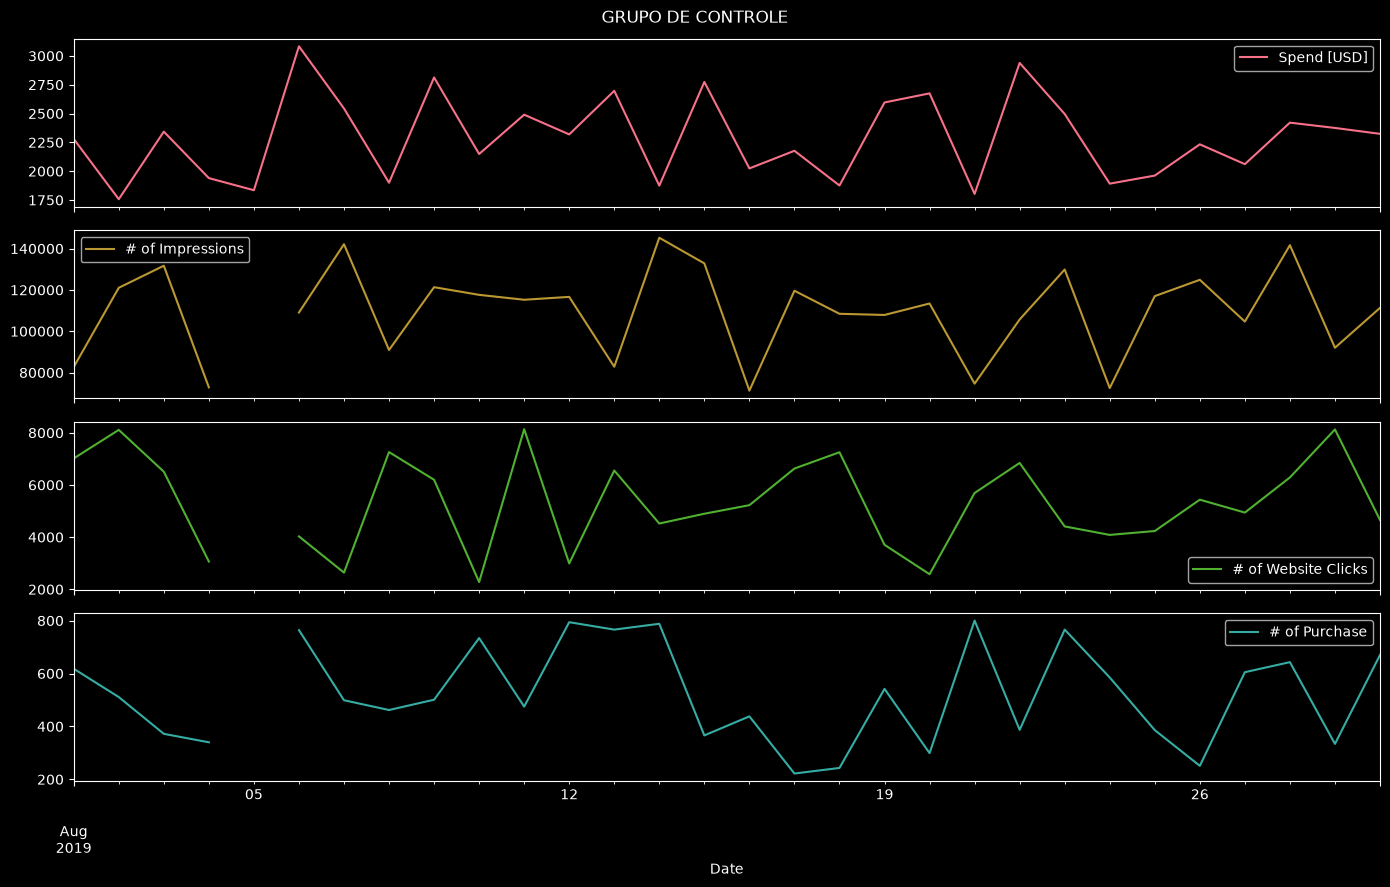

In [7]:
df.set_index("Date")[["Spend [USD]", "# of Impressions", "# of Website Clicks", "# of Purchase"]].plot(
    subplots=True, figsize=(14, 9), sharex=True, title="GRUPO DE CONTROLE"
)
plt.tight_layout()
plt.show()